<a href="https://colab.research.google.com/github/sasvi123/GPA_cal/blob/main/nisal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

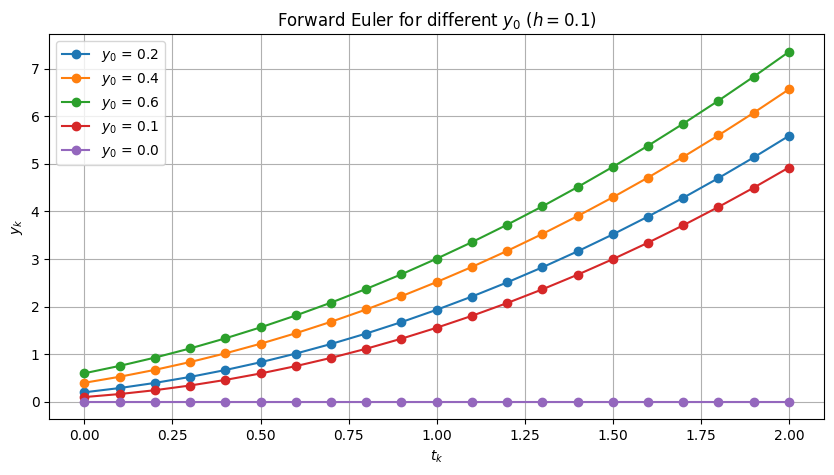

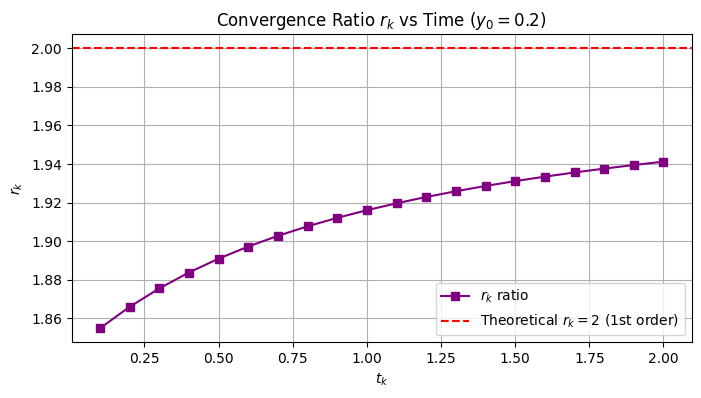

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1(a) Core Forward Euler Function
# ==========================================
def forward_euler(h, y0, t_end=2.0, func_type='sqrt'):
    """
    Simulates dy/dt = f(t, y) using Forward Euler.
    func_type options: 'sqrt' -> 2*sqrt(y), 'linear' -> 2*y, 'affine' -> 2*(1+y)
    """
    t_start = 0.0
    N = int(round((t_end - t_start) / h))
    t = np.linspace(t_start, t_end, N + 1)
    y = np.zeros(N + 1)
    y[0] = y0

    for k in range(N):
        if func_type == 'sqrt':
            # handle potential slight negative values due to numerical precision
            val = max(0.0, y[k])
            f = 2 * np.sqrt(val)
        elif func_type == 'linear':
            f = 2 * y[k]
        elif func_type == 'affine':
            f = 2 * (1 + y[k])

        y[k+1] = y[k] + h * f

    return t, y

# ==========================================
# 1(b) Analytical Solution
# ==========================================
def exact_sol_q1(t, y0):
    # Analytical solution for dy/dt = 2*sqrt(y) is y(t) = (t + sqrt(y0))^2
    return (t + np.sqrt(y0))**2

# ==========================================
# Execution and Plotting for Q1
# ==========================================
if __name__ == "__main__":
    # --- Part (a) Plotting different initial conditions ---
    initial_conditions = [0.2, 0.4, 0.6, 0.1, 0.0]
    plt.figure(figsize=(10, 5))
    for y0 in initial_conditions:
        t_arr, y_arr = forward_euler(h=0.1, y0=y0, t_end=2.0)
        plt.plot(t_arr, y_arr, '-o', label=f'$y_0$ = {y0}')
    plt.title('Forward Euler for different $y_0$ ($h=0.1$)')
    plt.xlabel('$t_k$')
    plt.ylabel('$y_k$')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Part (c) Multi-step-size convergence and r_k ratio ---
    h1, h2, h3 = 0.1, 0.05, 0.025
    t1, y1 = forward_euler(h1, y0=0.2, t_end=2.0)
    t2, y2 = forward_euler(h2, y0=0.2, t_end=2.0)
    t3, y3 = forward_euler(h3, y0=0.2, t_end=2.0)

    # Calculate convergence ratio r_k
    # Lengths correspond to matching points in time
    rk = []
    tk_rk = []
    for k in range(1, len(y1)):
        num = y1[k] - y2[2*k]
        den = y2[2*k] - y3[4*k]
        if abs(den) > 1e-10: # avoid division by zero
            rk.append(num / den)
            tk_rk.append(t1[k])

    # Plot r_k against t_k
    plt.figure(figsize=(8, 4))
    plt.plot(tk_rk, rk, '-s', color='purple', label='$r_k$ ratio')
    plt.axhline(y=2.0, color='r', linestyle='--', label='Theoretical $r_k=2$ (1st order)')
    plt.title('Convergence Ratio $r_k$ vs Time ($y_0=0.2$)')
    plt.xlabel('$t_k$')
    plt.ylabel('$r_k$')
    plt.legend()
    plt.grid(True)
    plt.show()

<>:52: SyntaxWarning: invalid escape sequence '\i'
<>:92: SyntaxWarning: invalid escape sequence '\i'
<>:52: SyntaxWarning: invalid escape sequence '\i'
<>:92: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_950/4011293062.py:52: SyntaxWarning: invalid escape sequence '\i'
  plt.title('Explicit Midpoint vs Exact Solution ($t \in [0, 20]$)')
/tmp/ipykernel_950/4011293062.py:92: SyntaxWarning: invalid escape sequence '\i'
  plt.title('Effect of step size $h$ over long intervals ($t \in [0, 100]$)')


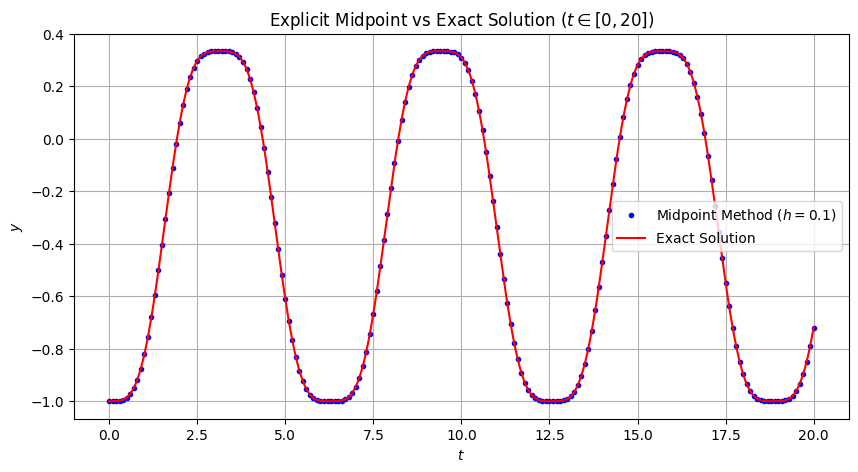

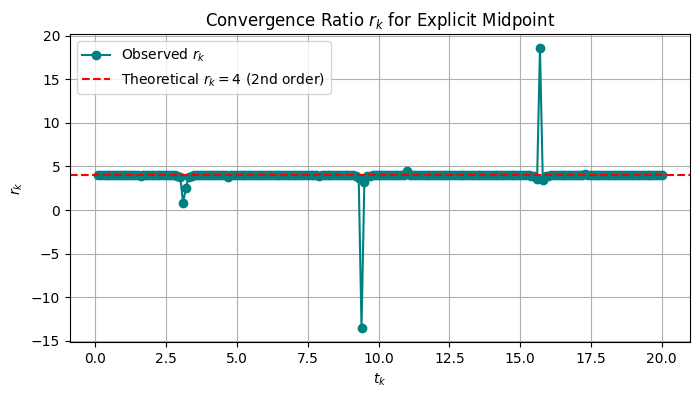

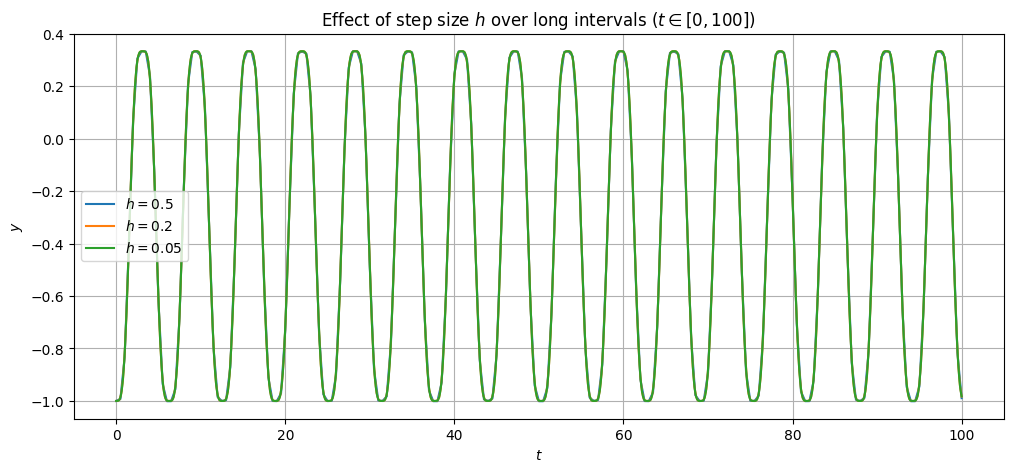

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 2(a) Explicit Midpoint Method Function
# ==========================================
def explicit_midpoint(h, y0, t_end=20.0):
    """
    Simulates dy/dt = sin^3(t) using Explicit Midpoint method.
    """
    t_start = 0.0
    N = int(round((t_end - t_start) / h))
    t = np.linspace(t_start, t_end, N + 1)
    y = np.zeros(N + 1)
    y[0] = y0

    for k in range(N):
        # Current values
        tk = t[k]
        yk = y[k]

        # Midpoint steps
        t_mid = tk + h / 2.0
        y_mid = yk + (h / 2.0) * (np.sin(tk)**3)

        # Full step
        y[k+1] = yk + h * (np.sin(t_mid)**3)

    return t, y

# ==========================================
# 2(b) Analytical Solution
# ==========================================
def exact_sol_q2(t):
    # Integral of sin^3(t) dt = 1/3 * cos^3(t) - cos(t)
    # Using y(0) = -1, the constant C = -1/3
    return (1.0/3.0) * (np.cos(t)**3) - np.cos(t) - (1.0/3.0)

# ==========================================
# Execution and Plotting for Q2 & Q3
# ==========================================
if __name__ == "__main__":
    # --- Part (a) Midpoint simulation for t in [0, 20] ---
    h_val = 0.1
    t_mid, y_mid = explicit_midpoint(h=h_val, y0=-1.0, t_end=20.0)
    t_exact = np.linspace(0, 20, 1000)
    y_exact = exact_sol_q2(t_exact)

    plt.figure(figsize=(10, 5))
    plt.plot(t_mid, y_mid, 'b.', label=f'Midpoint Method ($h={h_val}$)')
    plt.plot(t_exact, y_exact, 'r-', label='Exact Solution')
    plt.title('Explicit Midpoint vs Exact Solution ($t \in [0, 20]$)')
    plt.xlabel('$t$')
    plt.ylabel('$y$')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Part (b) Convergence ratio r_k for Second-Order Method ---
    h1, h2, h3 = 0.1, 0.05, 0.025
    _, Y1 = explicit_midpoint(h1, y0=-1.0, t_end=20.0)
    _, Y2 = explicit_midpoint(h2, y0=-1.0, t_end=20.0)
    _, Y3 = explicit_midpoint(h3, y0=-1.0, t_end=20.0)

    rk_mid = []
    tk_rk_mid = []
    t1_nodes = np.linspace(0, 20, len(Y1))

    for k in range(1, len(Y1)):
        num = Y1[k] - Y2[2*k]
        den = Y2[2*k] - Y3[4*k]
        if abs(den) > 1e-10:
            rk_mid.append(num / den)
            tk_rk_mid.append(t1_nodes[k])

    plt.figure(figsize=(8, 4))
    plt.plot(tk_rk_mid, rk_mid, '-o', color='teal', label='Observed $r_k$')
    plt.axhline(y=4.0, color='r', linestyle='--', label='Theoretical $r_k=4$ (2nd order)')
    plt.title('Convergence Ratio $r_k$ for Explicit Midpoint')
    plt.xlabel('$t_k$')
    plt.ylabel('$r_k$')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Part (c) Long-term tracking for t in [0, 100] ---
    plt.figure(figsize=(12, 5))
    for h_test in [0.5, 0.2, 0.05]:
        t_long, y_long = explicit_midpoint(h=h_test, y0=-1.0, t_end=100.0)
        plt.plot(t_long, y_long, label=f'$h = {h_test}$')

    plt.title('Effect of step size $h$ over long intervals ($t \in [0, 100]$)')
    plt.xlabel('$t$')
    plt.ylabel('$y$')
    plt.legend()
    plt.grid(True)
    plt.show()